# Natural Exponent

$$ e = 2.718... $$

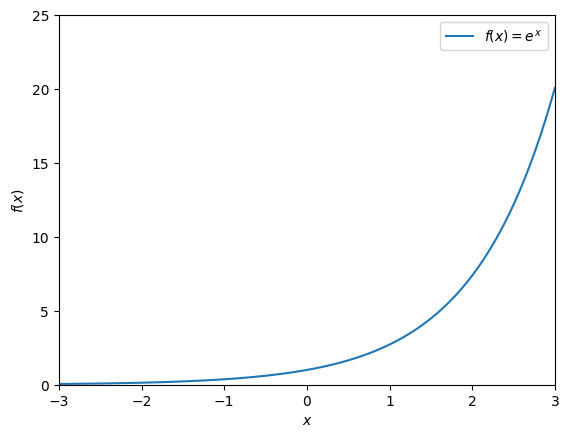

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3,3,1001)
x_exp = np.exp(x)

plt.plot(x,x_exp,label='$f(x)=e^x$')
plt.ylabel('$f(x)$')
plt.xlabel('$x$')
plt.xlim([-3,3])
plt.ylim([0,25])
plt.legend()
plt.show()

# The softmax formula

$$ \sigma_i = \frac{e^{z_i}}{\sum{e^z}} $$

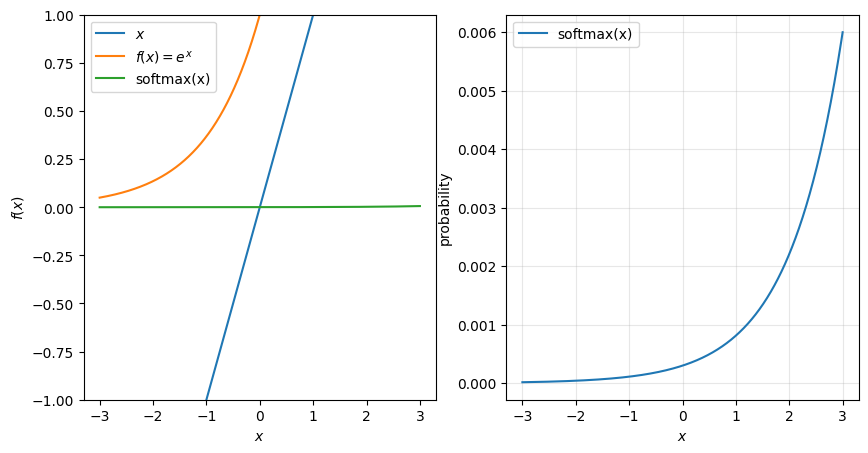

In [30]:
x_softmax = np.exp(x) / np.sum(np.exp(x))

fig, axs = plt.subplots(1,2,figsize=(10,5))

axs[0].plot(x,x,label='$x$')
axs[0].plot(x,x_exp,label='$f(x)=e^x$')
axs[0].plot(x,x_softmax,label='softmax(x)')
axs[0].set_ylabel('$f(x)$')
axs[0].set_xlabel('$x$')
axs[0].set_ylim([-1,1])
axs[0].legend()

axs[1].plot(x, x_softmax, label='softmax(x)')
axs[1].set_xlabel('$x$')
axs[1].set_ylabel('probability')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

Its a probability function:

$$\text{Non-negativity} \rightarrow p(x) \geq 0, \forall x \in X$$
$$ \text{Normalization} \rightarrow \int_{-\infty}^{\infty} p(x)\,dx = 1$$

# Temperature

$$ \sigma_i = \frac{\exp(z_i/T)}{\sum \exp (z/T)} $$

$T$ - typically $>1$, the higher the probability is smoother, i.e. higher values pop up less.

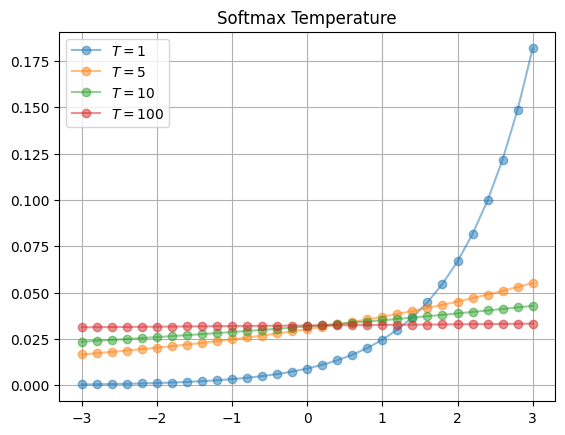

In [28]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3,3,31)

T = 1
x_softmax = np.exp(x/T) / np.sum(np.exp(x/T))
plt.plot(x, x_softmax, '-o', label = f'$T = {T}$', alpha = .5)

T = 5
x_softmax = np.exp(x/T) / np.sum(np.exp(x/T))
plt.plot(x, x_softmax, '-o', label = f'$T = {T}$', alpha = .5)

T = 10
x_softmax = np.exp(x/T) / np.sum(np.exp(x/T))
plt.plot(x, x_softmax, '-o',label = f'$T = {T}$', alpha = .5)

T = 100
x_softmax = np.exp(x/T) / np.sum(np.exp(x/T))
plt.plot(x, x_softmax, '-o', label = f'$T = {T}$', alpha = .5)

plt.legend()

plt.title('Softmax Temperature')
plt.grid()

plt.show()

# Softmax vs Log-softmax

$$ log-softmax = log\Big(\frac{e^{z_i}}{\sum e^z} \Big) $$

* Log-softmax "stretches" out the penalties for incorrect guesses, which improves category separability and increase numerical stability.
* Lin-softmax (traditional softmax) works fine on problems with a "small number" of categories, or when catgories are easily differentiable


$$ \text{logn-softmax} = \log\Big(\frac{\exp(x_{i})}{\sum\exp(x)}\Big) = \log\Big(\exp(x_i)\Big) - log\Big(\sum\exp(x)\Big) = x_i - log\Big(\sum(\exp(x))\Big) $$

As we can see we subtract from $x_i$ constant value, i.e. $\text{log-softmax}$ looks line a straight line.

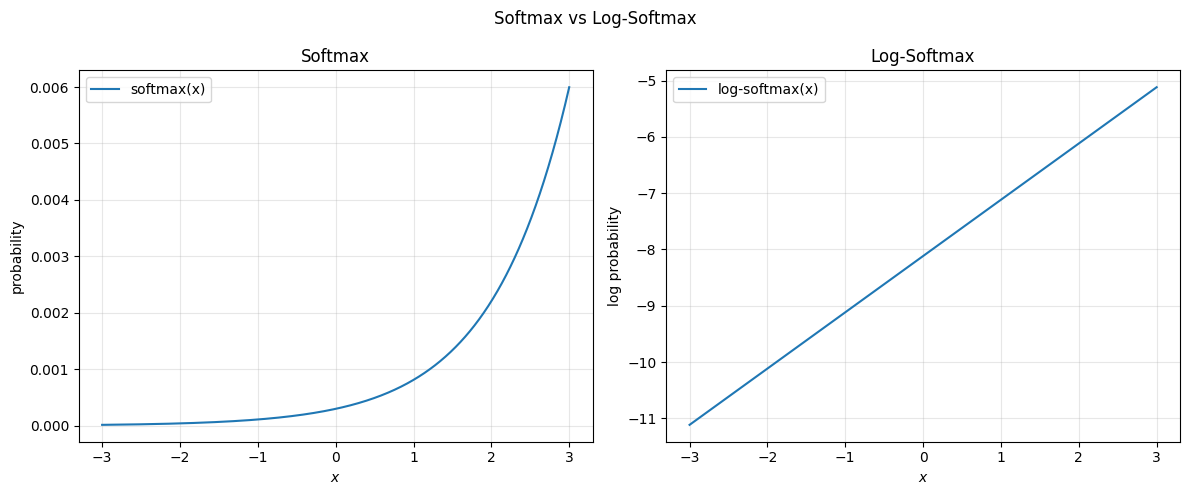

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 1001)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# stable softmax
x_shifted = x - np.max(x)
x_softmax = np.exp(x_shifted) / np.sum(np.exp(x_shifted))

# stable log-softmax
x_log_softmax = x_shifted - np.log(np.sum(np.exp(x_shifted)))

axs[0].plot(x, x_softmax, label='softmax(x)')
axs[0].set_title('Softmax')
axs[0].set_xlabel('$x$')
axs[0].set_ylabel('probability')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(x, x_log_softmax, label='log-softmax(x)')
axs[1].set_title('Log-Softmax')
axs[1].set_xlabel('$x$')
axs[1].set_ylabel('log probability')
axs[1].legend()
axs[1].grid(alpha=0.3)

fig.suptitle('Softmax vs Log-Softmax')
plt.tight_layout()
plt.show()

# Numpy Implementation

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [3]:
z = [1,2,3]

num = np.exp(z)
den = np.sum(np.exp(z))
sigma = num / den

print(sigma)
print(np.sum(sigma))

[0.09003057 0.24472847 0.66524096]
1.0


[ 6  5 -3 12 -5  3 14 10 10  0 14 10 -5 13 10 -2  4 -2 12  9  6  5 13  7
 10]


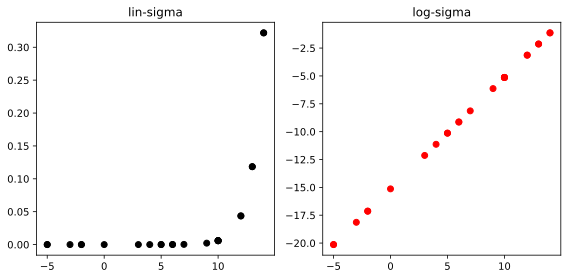

In [20]:
# repeat with some random integers
z = np.random.randint(-5, high = 15, size = 25)
print(z)

# compute the softmax result
num = np.exp(z)
den = np.sum(num)
sigma = num / den
log_sigma = np.log(sigma)

_, axs = plt.subplots(1,2,figsize=(8,4))

# compare
axs[0].plot(z, sigma, 'ko', label = 'lin-softmax')
axs[0].set_title('lin-sigma')
axs[1].plot(z, log_sigma, 'ro', label = 'log-softmax')
axs[1].set_title('log-sigma')

plt.tight_layout()
plt.show()

# PyTorch Implmenation

/tmp/ipykernel_18915/16764847.py:3: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(z_torch, F.softmax(z_torch), 'o')


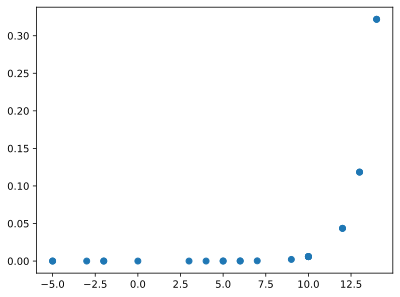

In [27]:
z_torch = torch.tensor(z, dtype = torch.float64)

plt.plot(z_torch, F.softmax(z_torch), 'o')
plt.show()

# Temperature Torch

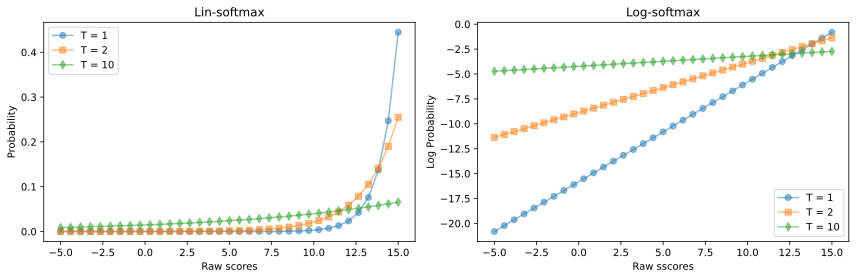

In [48]:
temperatures = [1,2,10]

raw_scores = torch.linspace(-5,15,35)
shapes = 'osd'

_, axs = plt.subplots(1,2,figsize=(12,4))
for temp, s in zip(temperatures, shapes):

  # scale the scores by temperature
  heated_scores = raw_scores / temp

  axs[0].plot(raw_scores, F.softmax(heated_scores, dim = 0), f'{s}-', alpha = 0.5,label = f'T = {temp}')
  axs[1].plot(raw_scores, F.log_softmax(heated_scores, dim = 0), f'{s}-', alpha = 0.5, label = f'T = {temp}')

axs[0].set(xlabel = 'Raw scores', ylabel = 'Probability', title = 'Lin-softmax')
axs[0].legend()
axs[1].set(xlabel = 'Raw sscores', ylabel = 'Log Probability', title = 'Log-softmax')
axs[1].legend()

plt.tight_layout()
plt.show()